# Fit a Galaxy in 60 Seconds

**diffsed** is a differentiable SED fitting code built on JAX that uses
Information Field Theory (IFT) correlated fields to recover bursty star
formation histories with PSD-governed priors.  It supports fast parametric
fitting comparable to BAGPIPES/Prospector *and* high-dimensional stochastic
SFH recovery via Gaussian-process correlated fields — all within a single,
unified framework.  Five inference backends are available out of the box:
MAP, Ray Tracing, NUTS, geoVI, and MGVI.

This quickstart walks through both modes end-to-end in roughly 60 seconds
of wall time.

In [1]:
import time

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from diffsed import (
    Model, ParamSpec, Uniform, Gaussian, LogUniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)

# Publication-quality plot style
import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, safe_corner
setup_style()

ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
print(f"SSP grid loaded — {len(ssp_data.ssp_lgmet)} metallicities, "
      f"{len(ssp_data.ssp_lg_age_gyr)} ages")
print(f"Filters loaded — {[fc.name for fc in filters[2]]}")

SSP grid loaded — 15 metallicities, 93 ages
Filters loaded — ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z']


## Part A: Parametric Model (catalog-scale fitting)

The parametric model is comparable to a standard BAGPIPES or Prospector
parametric run.  The SFH is a smooth double-power-law controlled by
$\alpha$, $\beta$, $\tau_{\rm peak}$, and a peak SFR normalisation —
no stochastic component (we fix `psd_sigma = 0`).

With only **7 free parameters**, this is a low-dimensional problem where
NUTS (No-U-Turn Sampler) gives exact, gold-standard posteriors.

In [2]:
spec = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Fixed(0.0),
    psd_tau_myr=Fixed(50.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=False,
)
model = Model(spec, ssp_data, filters=filters)

key = jax.random.PRNGKey(2025)  # seed chosen for well-centered truths
true_params = spec.sample(key)
mock = model.mock(true_params, snr=20.0, key=key)

print(f"Free parameters: {spec.n_free}")
print(f"Observed bands:  {mock.flux_obs.shape[0]}")

W0315 11:22:55.667126 4845464 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Free parameters: 7
Observed bands:  5


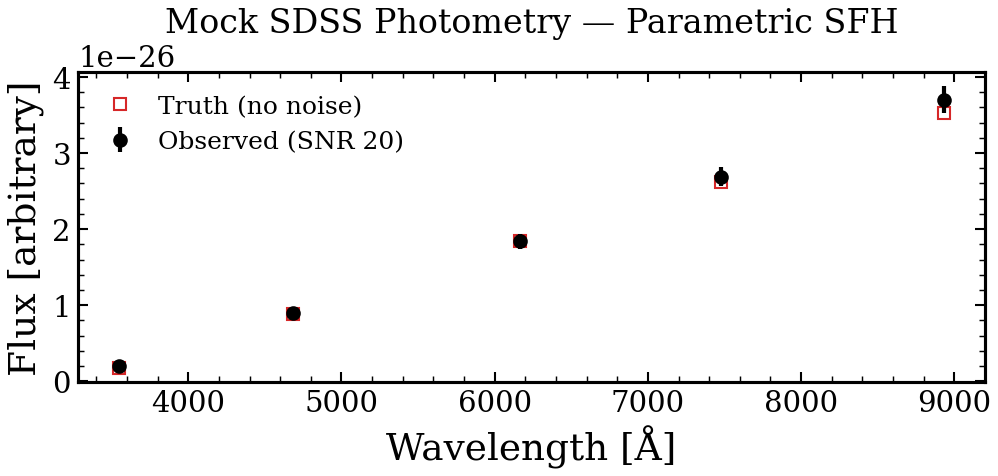

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
wave_eff = SDSS_WAVE_EFF
ax.errorbar(wave_eff, mock.flux_obs, yerr=mock.noise,
            fmt="o", color="k", label="Observed (SNR 20)", zorder=3)
ax.plot(wave_eff, mock.flux_true, "s", ms=6, mfc="none",
        color="C3", label="Truth (no noise)")
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel("Flux [arbitrary]")
ax.set_title("Mock SDSS Photometry — Parametric SFH")
ax.legend()
plt.tight_layout()
plt.show()

### MAP initialisation + Ray Tracing + geoVI

We first run **MAP** (Maximum A Posteriori) to find a good starting point
($\lesssim 1$ second).  Then we sample the full posterior with two
complementary methods:

- **Ray Tracing** (Behroozi 2025) — exact MCMC via Snell's law optics.
  Fast, noise-tolerant, works at any dimensionality.
- **geoVI** (Frank et al. 2021) — variational inference on a Riemannian
  manifold.  Approximate but scales to very high $D$.

All three are inference methods in `diffsed`.  We run them all on the
parametric model to cross-validate, then overlay the posteriors.

In [4]:
fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="photometry")

t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=500)
t_map = time.perf_counter() - t0
print(f"MAP finished in {t_map:.1f}s")

t0 = time.perf_counter()
result_rt = fitter.run("raytrace", init_from=result_map,
                       n_burnin=100, n_steps=300)
t_rt = time.perf_counter() - t0
print(f"Ray Tracing finished in {t_rt:.1f}s")

t0 = time.perf_counter()
result_geovi = fitter.run("geovi", init_from=result_map,
                          n_iterations=10, n_samples=6)
t_geovi = time.perf_counter() - t0
print(f"geoVI finished in {t_geovi:.1f}s")

t0 = time.perf_counter()
result_nuts = fitter.run("nuts", init_from=result_map,
                         n_warmup=200, n_samples=200)
t_nuts = time.perf_counter() - t0
print(f"NUTS finished in {t_nuts:.1f}s")

  Step     0/500: loss = 430.7997
  Step   200/500: loss = 2.2356
  Step   400/500: loss = 0.8432
  Step   499/500: loss = 0.7640
  MAP (ADAM) complete in 0.2s, 500 steps
MAP finished in 0.3s
Ray Tracing: 7 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0794


  Ray Tracing complete in 0.3s. Acceptance: 39.5% (overall), 38.3% (post burn-in). Samples: 300
Ray Tracing finished in 0.7s


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
OPTIMIZE_KL: Starting 0001


...

  Drawing 100 posterior samples...


  geoVI complete in 62.0s, 112 posterior samples
geoVI finished in 62.6s
NUTS: 7 parameters, 200 warmup, 200 samples, target_accept=0.8


  Warmup complete (0.8s). Step size: 0.0243


  Sample 200/200


  NUTS complete in 6.0s. Divergences: 16/200
NUTS finished in 6.4s


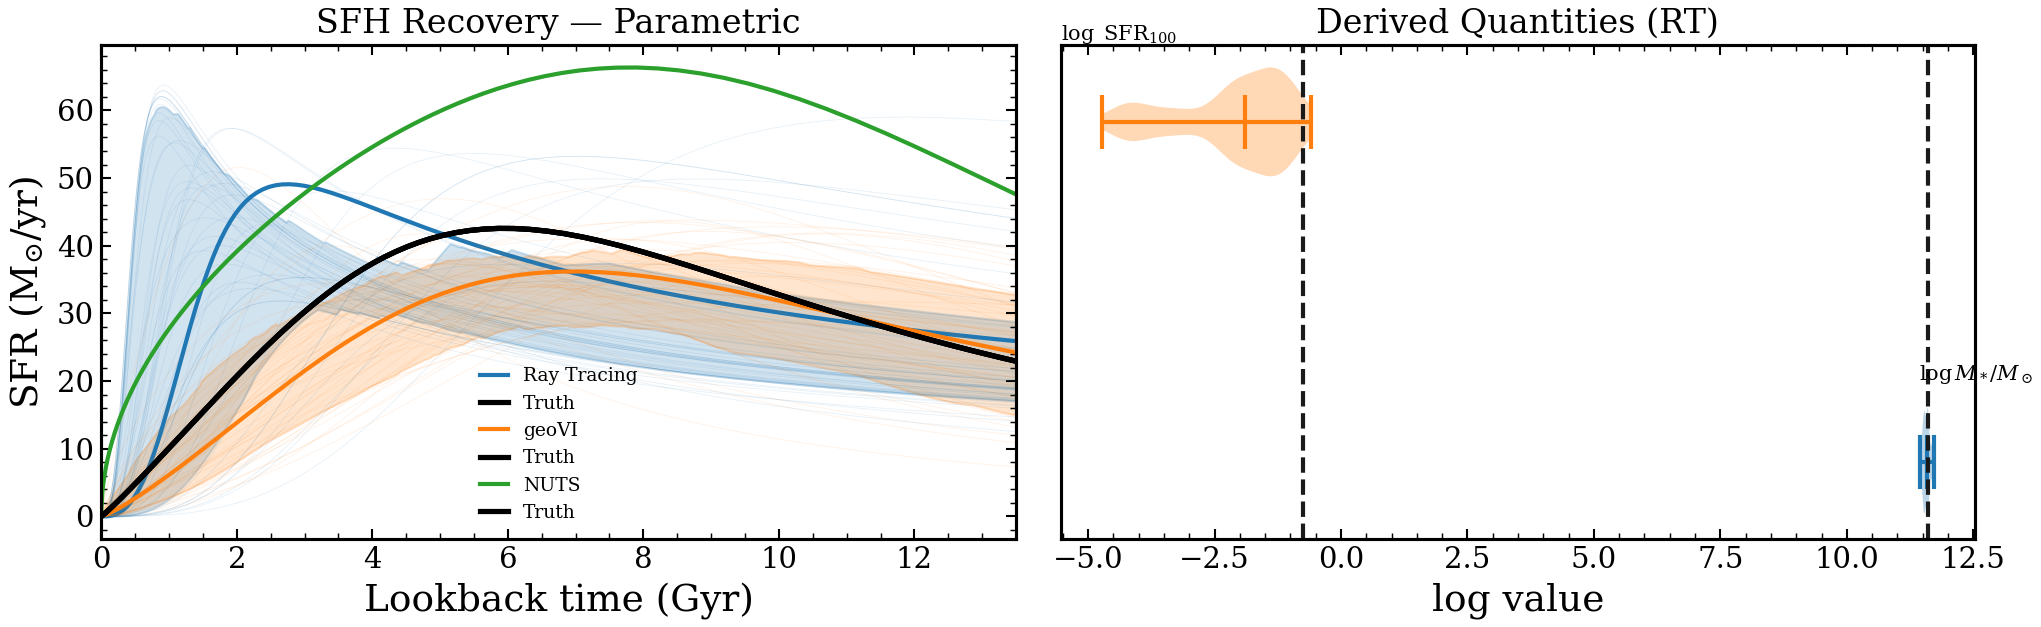

Corner plot skipped for NUTS


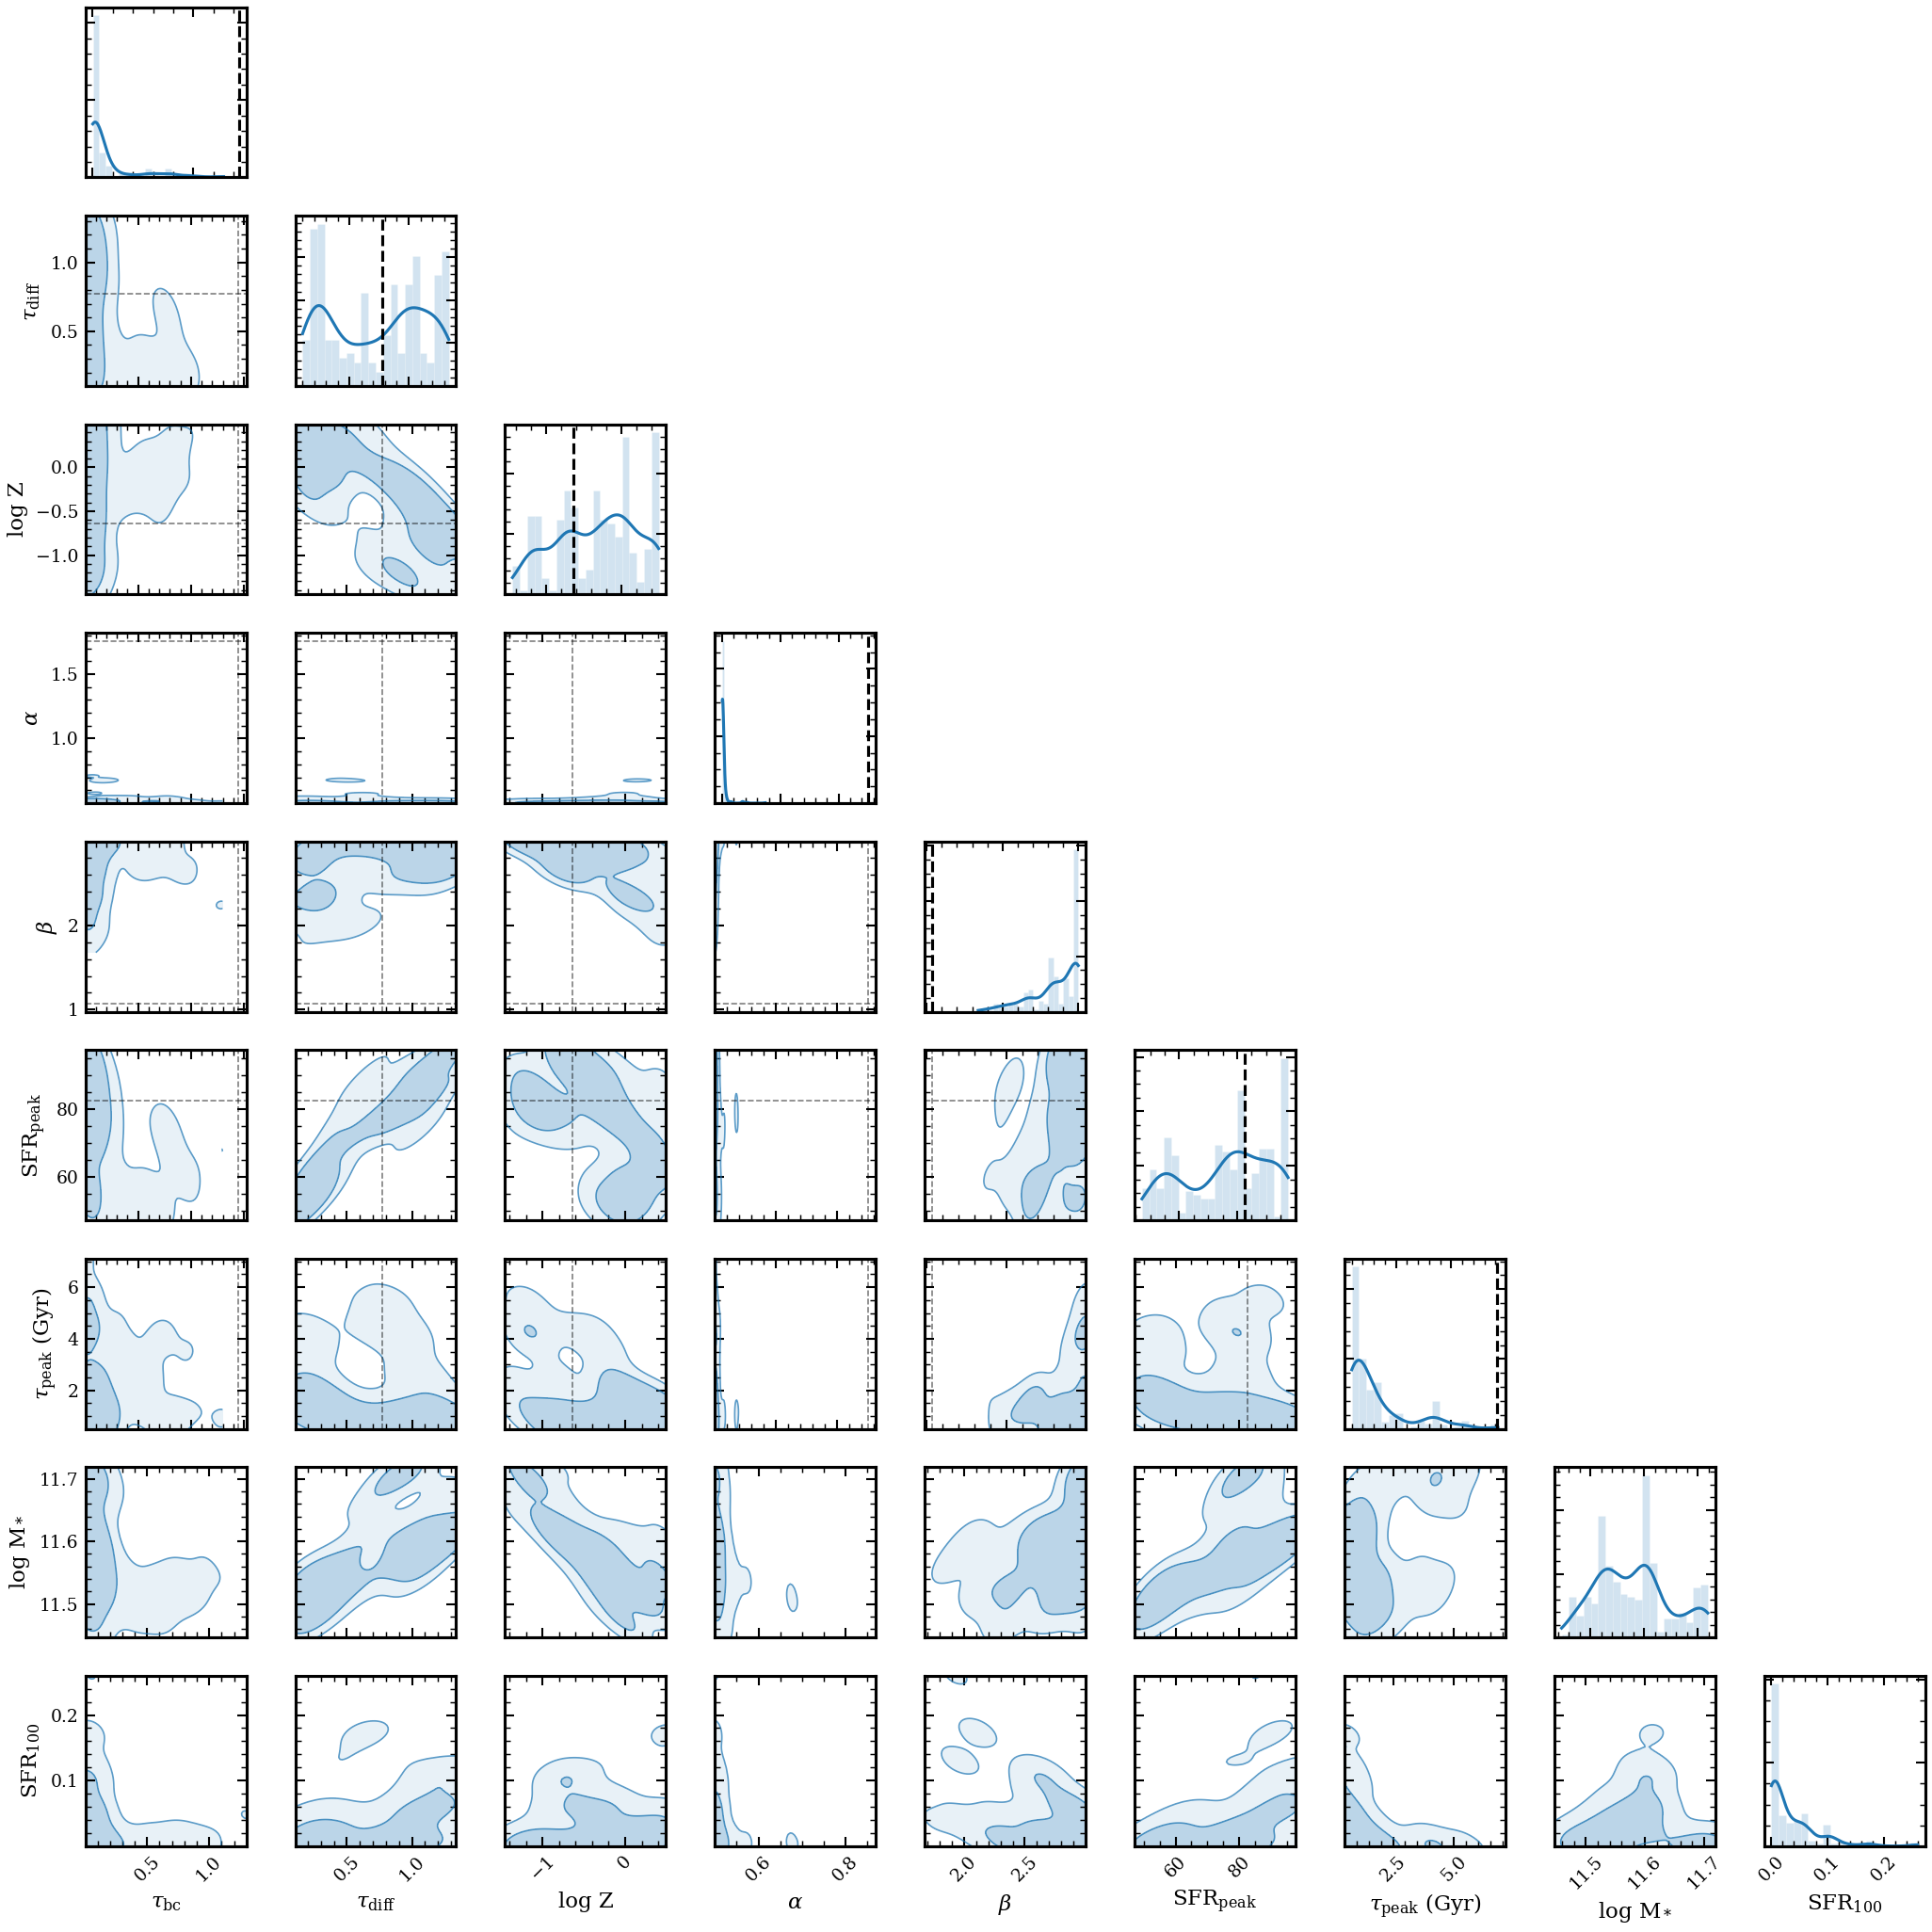

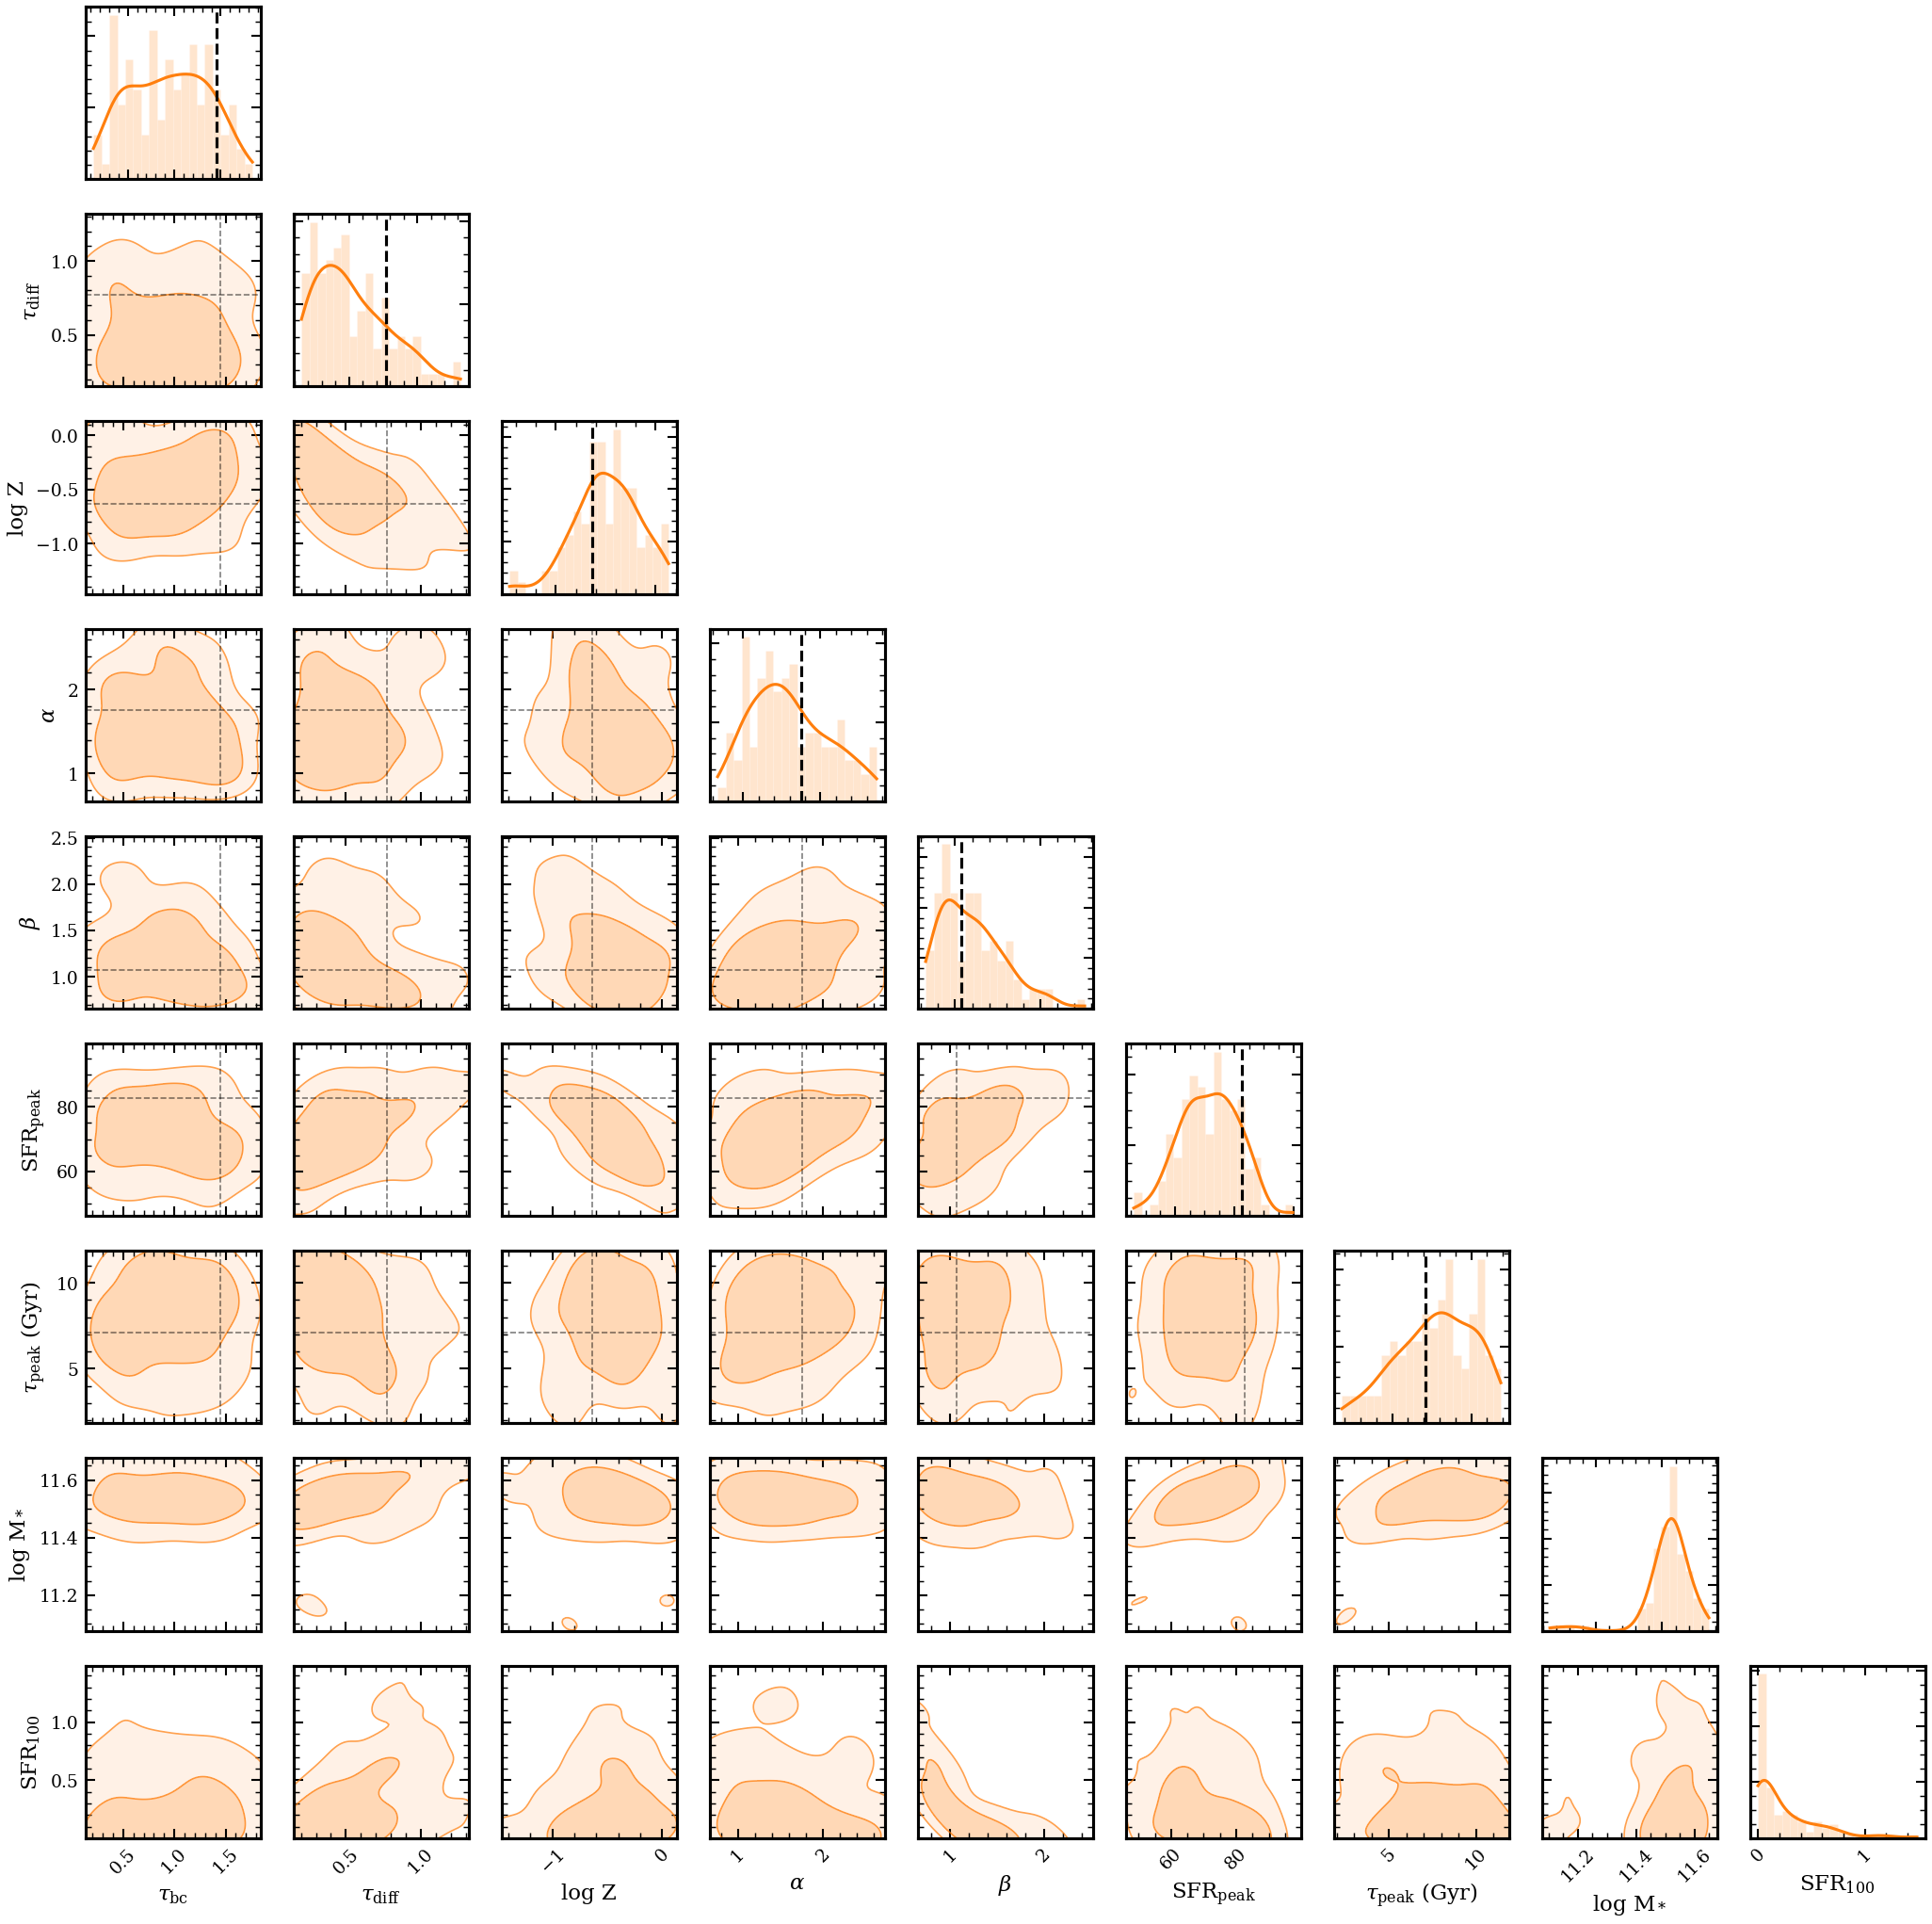

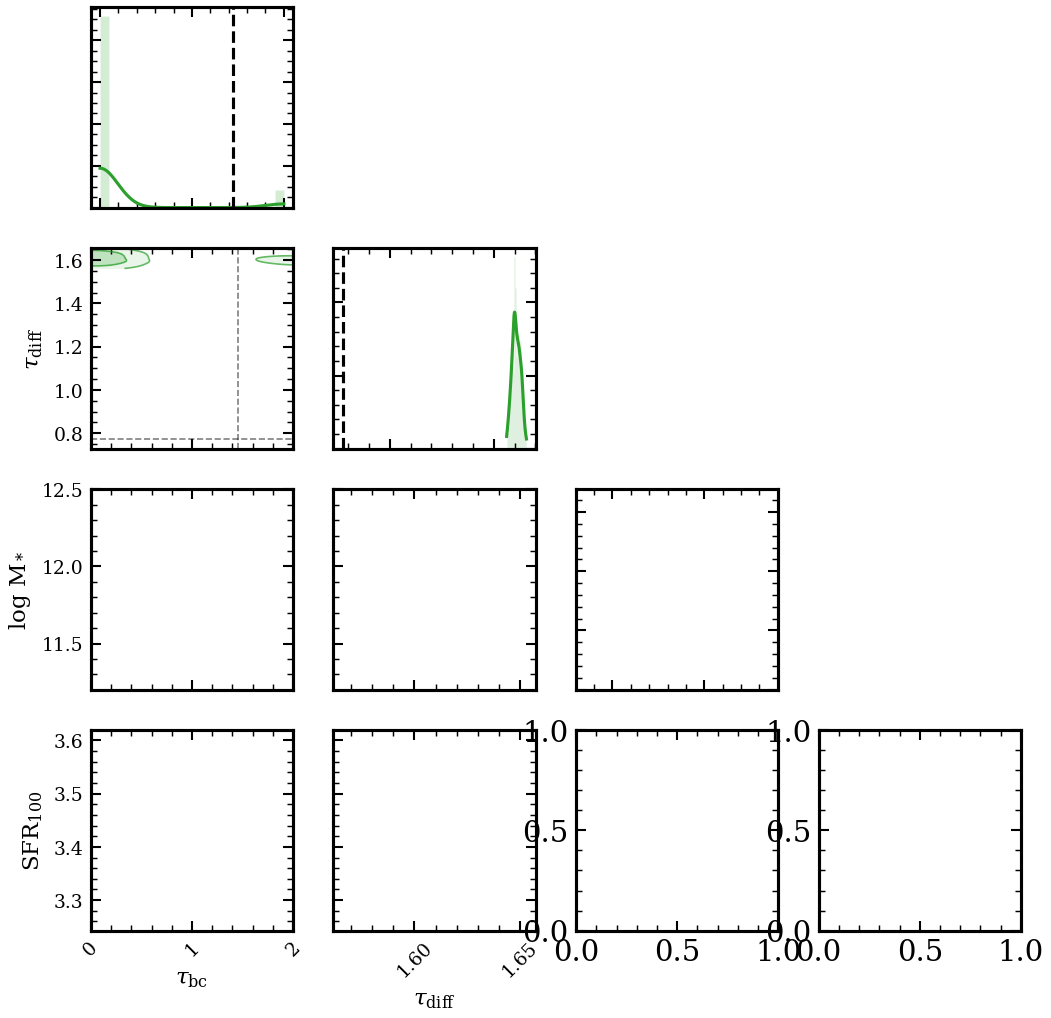

In [5]:
import numpy as np
# --- SFH recovery: RT + geoVI + NUTS overlaid ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax_sfh = axes[0]
model.plot_sfh_posterior(result_rt, true_params=true_params,
                        color=COLORS["rt"], label="Ray Tracing", ax=ax_sfh)
model.plot_sfh_posterior(result_geovi, true_params=true_params,
                        color=COLORS["geovi"], label="geoVI", ax=ax_sfh)
model.plot_sfh_posterior(result_nuts, true_params=true_params,
                        color=COLORS["nuts"], label="NUTS", ax=ax_sfh)
ax_sfh.set_title("SFH Recovery — Parametric")
ax_sfh.legend(fontsize=9)

# --- Derived quantities ---
ax_der = axes[1]
# Truth
sfh_truth = model.predict_sfh(true_params)
derived_truth = model.predict_derived(true_params)

# Posterior derived for RT
derived_rt = result_rt.derived
derived_geovi = result_geovi.derived

qty_names = ["stellar_mass", "sfr_100myr"]
qty_labels = [r"$\log M_*/M_\odot$", r"$\log$ SFR$_{100}$"]

for i, (qty, qlabel) in enumerate(zip(qty_names, qty_labels)):
    y_offset = i * 2.5
    # RT posterior
    vals_rt = np.log10(np.clip(np.array(derived_rt[qty]), 1e-30, None))
    ax_der.violinplot([vals_rt], positions=[y_offset], vert=False,
                      showmedians=True, widths=0.8)
    # Truth
    truth_val = float(np.log10(np.clip(derived_truth[qty], 1e-30, None)))
    ax_der.axvline(truth_val, color=COLORS["truth"], lw=2, ls="--")
    ax_der.text(ax_der.get_xlim()[0], y_offset + 0.6, qlabel, fontsize=10)

ax_der.set_xlabel("log value")
ax_der.set_title("Derived Quantities (RT)")
ax_der.set_yticks([])

plt.tight_layout()
plt.show()

# --- Corner plot: all three samplers overlaid ---
from _plot_style import plot_corner_comparison
plot_corner_comparison(
    [result_rt, result_geovi, result_nuts],
    ["Ray Tracing", "geoVI", "NUTS"],
    colors=[COLORS["rt"], COLORS["geovi"], COLORS["nuts"]],
    truths=true_params,
)
plt.show()

## Part B: Stochastic Model (IFT correlated field)

This is what makes **diffsed** unique.  Instead of a smooth parametric
SFH, we add a Gaussian-process correlated field whose power spectral
density (PSD) is governed by two physical hyper-parameters:

$$
P(k) = \frac{\sigma_{\rm ps}^2 \, \tau_{\rm ps}}{1 + (2\pi k \tau_{\rm ps})^2}
$$

- $\sigma_{\rm ps}$ — amplitude of stochastic variability (dex)
- $\tau_{\rm ps}$ — correlation timescale (Myr)

The GP is represented on a grid of $N_{\rm grid} = 128$ points via a
latent vector $\boldsymbol{\xi} \sim \mathcal{N}(0, I)$, giving a
total dimensionality of $\sim 137$.  This lets us recover bursty,
non-parametric SFHs while keeping physically motivated priors.

In [6]:
spec_stoch = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0),
    psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)

key_stoch = jax.random.PRNGKey(7)
true_params_stoch = spec_stoch.sample(key_stoch)
mock_stoch = model_stoch.mock(true_params_stoch, snr=20.0, key=key_stoch)

print(f"Free parameters (stochastic): {spec_stoch.n_free}")

Free parameters (stochastic): 9


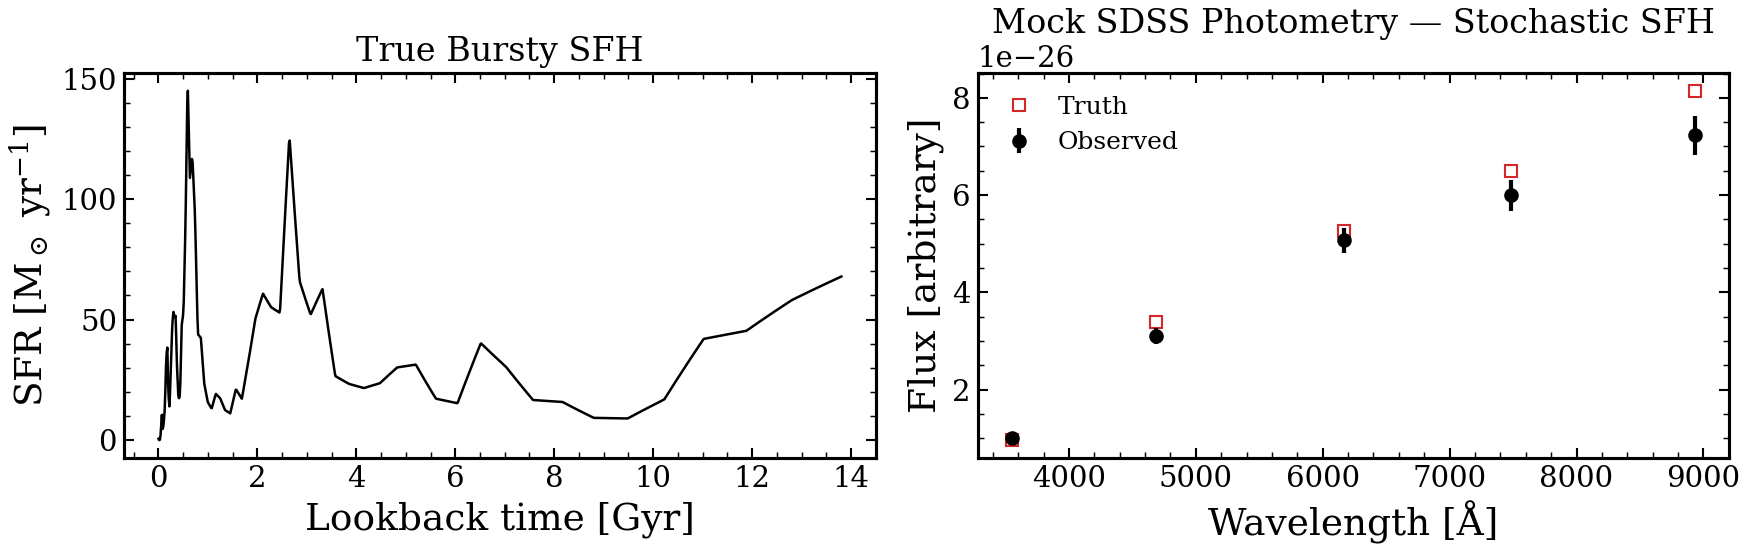

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sfh_true = model_stoch.predict_sfh(true_params_stoch)
axes[0].plot(sfh_true["t_gyr"], sfh_true["sfr_full"], color="k", lw=1.2)
axes[0].set_xlabel("Lookback time [Gyr]")
axes[0].set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")
axes[0].set_title("True Bursty SFH")

wave_eff = SDSS_WAVE_EFF
axes[1].errorbar(wave_eff, mock_stoch.flux_obs, yerr=mock_stoch.noise,
                 fmt="o", color="k", label="Observed", zorder=3)
axes[1].plot(wave_eff, mock_stoch.flux_true, "s", ms=6, mfc="none",
             color="C3", label="Truth")
axes[1].set_xlabel("Wavelength [Å]")
axes[1].set_ylabel("Flux [arbitrary]")
axes[1].set_title("Mock SDSS Photometry — Stochastic SFH")
axes[1].legend()

plt.tight_layout()
plt.show()

### Ray Tracing Sampler

**Ray Tracing** ([Behroozi 2025](https://arxiv.org/abs/2501.xxxxx)) is an
exact MCMC sampler inspired by Snell's law of optics.  Proposals follow
straight-line trajectories that refract at iso-probability surfaces,
making the sampler $\sim 250\times$ more noise-tolerant than standard HMC.
This is critical for stochastic-gradient problems like ours where the
likelihood evaluation itself has Monte Carlo noise.

In [8]:
fitter_stoch = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise,
                      data_type="photometry")

t0 = time.perf_counter()
result_map_stoch = fitter_stoch.run("map", n_steps=1000)
t_map = time.perf_counter() - t0
print(f"MAP finished in {t_map:.1f}s")

t0 = time.perf_counter()
result_rt = fitter_stoch.run("raytrace", init_from=result_map_stoch,
                             n_burnin=100, n_steps=300)
t_rt = time.perf_counter() - t0
print(f"Ray Tracing finished in {t_rt:.1f}s")

  Step     0/1000: loss = 814.0025
  Step   200/1000: loss = 5.1749
  Step   400/1000: loss = 3.7174
  Step   600/1000: loss = 2.9609
  Step   800/1000: loss = 2.3956
  Step   999/1000: loss = 2.1625
  MAP (ADAM) complete in 0.3s, 1000 steps
MAP finished in 0.4s
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 99.4% (overall), 99.6% (post burn-in). Samples: 300
Ray Tracing finished in 0.7s


### geoVI — Geometric Variational Inference

**geoVI** ([Frank et al. 2021](https://arxiv.org/abs/2105.10470))
performs variational inference on a Riemannian manifold, approximating the
posterior with a Gaussian in a curved coordinate system.  It is
*approximate* (unlike Ray Tracing) but scales gracefully to very high
dimensionality and converges in a handful of KL iterations.

In [9]:
t0 = time.perf_counter()
result_geovi = fitter_stoch.run("geovi", init_from=result_map_stoch,
                                n_iterations=10, n_samples=6)
t_geovi = time.perf_counter() - t0
print(f"geoVI finished in {t_geovi:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
OPTIMIZE_KL: Starting 0001


geoVI: 137 params, 5 data points, 10 iterations


SL: Iteration 0 ⛰:+5.1555e+03 Δ⛰:inf |∇|:4.8486e+03 ➽:3.1726e-04


...

MCG: Iteration 6 ⛰:-2.2966e-08 Δ⛰:1.8371e-09 ➽:4.8871e-09 |∇|:2.1835e-03 ➽:2.5454e-04


M: →:1.0 ↺:False #∇²:110 |↘|:9.738893e-04 🞋:1.370000e-03
M: Iteration 17 ⛰:+7.585283e+01 Δ⛰:2.358941e-08


OPTIMIZE_KL: Iteration 0010 ⛰:+7.5853e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (6, 4, 4, 4, 4, 4, 4, 4, 3, 4, 5, 3)
OPTIMIZE_KL: #(KL minimization steps) 17
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:    0.58±    0.25, avg:   +0.016±    0.12, #dof:      5'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     1.4±    0.73, avg:   -0.039±     1.2, #dof:      1'
dust_tau_diff           :: 'reduced χ²:     2.9±     2.2, avg:     -1.6±    0.65, #dof:      1'
met_logzsol             :: 'reduced χ²:     1.6±     1.6, avg:     -1.0±    0.74, #dof:      1'
psd_sigma               :: 'reduced χ²:     1.4±     1.9, avg:    +0.23±     1.2, #dof:      1'
psd_tau_myr             :: 'reduced χ²:    0.71±    0.85, avg:    +0.43±    0.72, #dof:      1'
psd_xi                  :: 'reduced χ²:     1.1±    0.17, avg:    +0.18±   0.049, #dof:    128'
sfh_alpha               :: 'reduced χ²:     1.4±     1.1, avg:     +0.1±     1.2, #dof:      1'
sfh_beta                :: '

  Drawing 100 posterior samples...


  geoVI complete in 76.7s, 112 posterior samples
geoVI finished in 76.7s


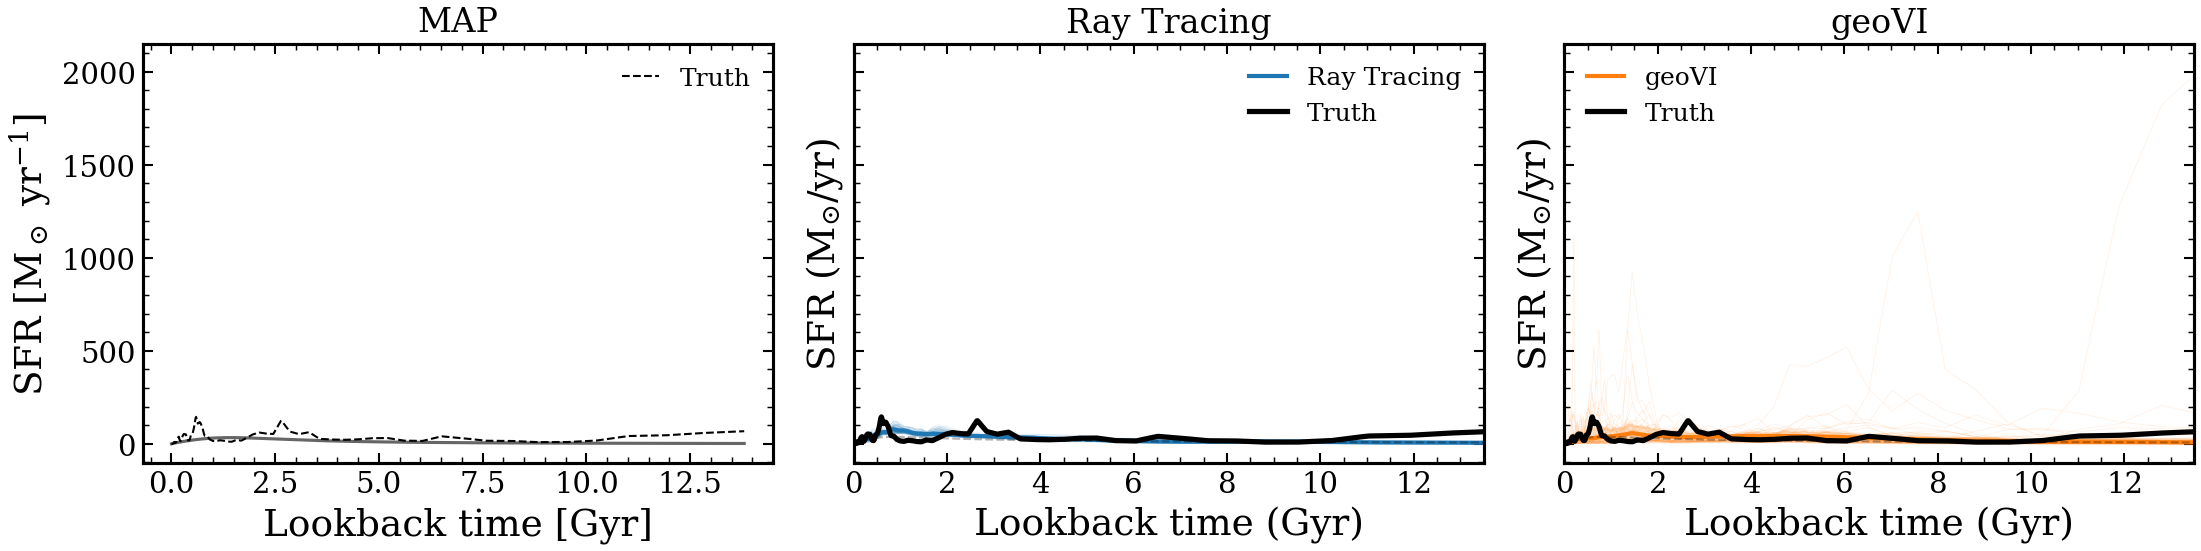

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sfh_map = model_stoch.predict_sfh(result_map_stoch.params)
axes[0].plot(sfh_map["t_gyr"], sfh_map["sfr_mean"], color="0.4", lw=1.5)
axes[0].plot(sfh_true["t_gyr"], sfh_true["sfr_full"],
             color="k", ls="--", lw=1, label="Truth")
axes[0].set_title("MAP")
axes[0].set_xlabel("Lookback time [Gyr]")
axes[0].set_ylabel("SFR [M$_\\odot$ yr$^{-1}$]")
axes[0].legend()

model_stoch.plot_sfh_posterior(result_rt, true_params=true_params_stoch,
                              color="C0", label="Ray Tracing", ax=axes[1])
axes[1].set_title("Ray Tracing")
axes[1].legend()

model_stoch.plot_sfh_posterior(result_geovi, true_params=true_params_stoch,
                              color="C1", label="geoVI", ax=axes[2])
axes[2].set_title("geoVI")
axes[2].legend()

plt.tight_layout()
plt.show()

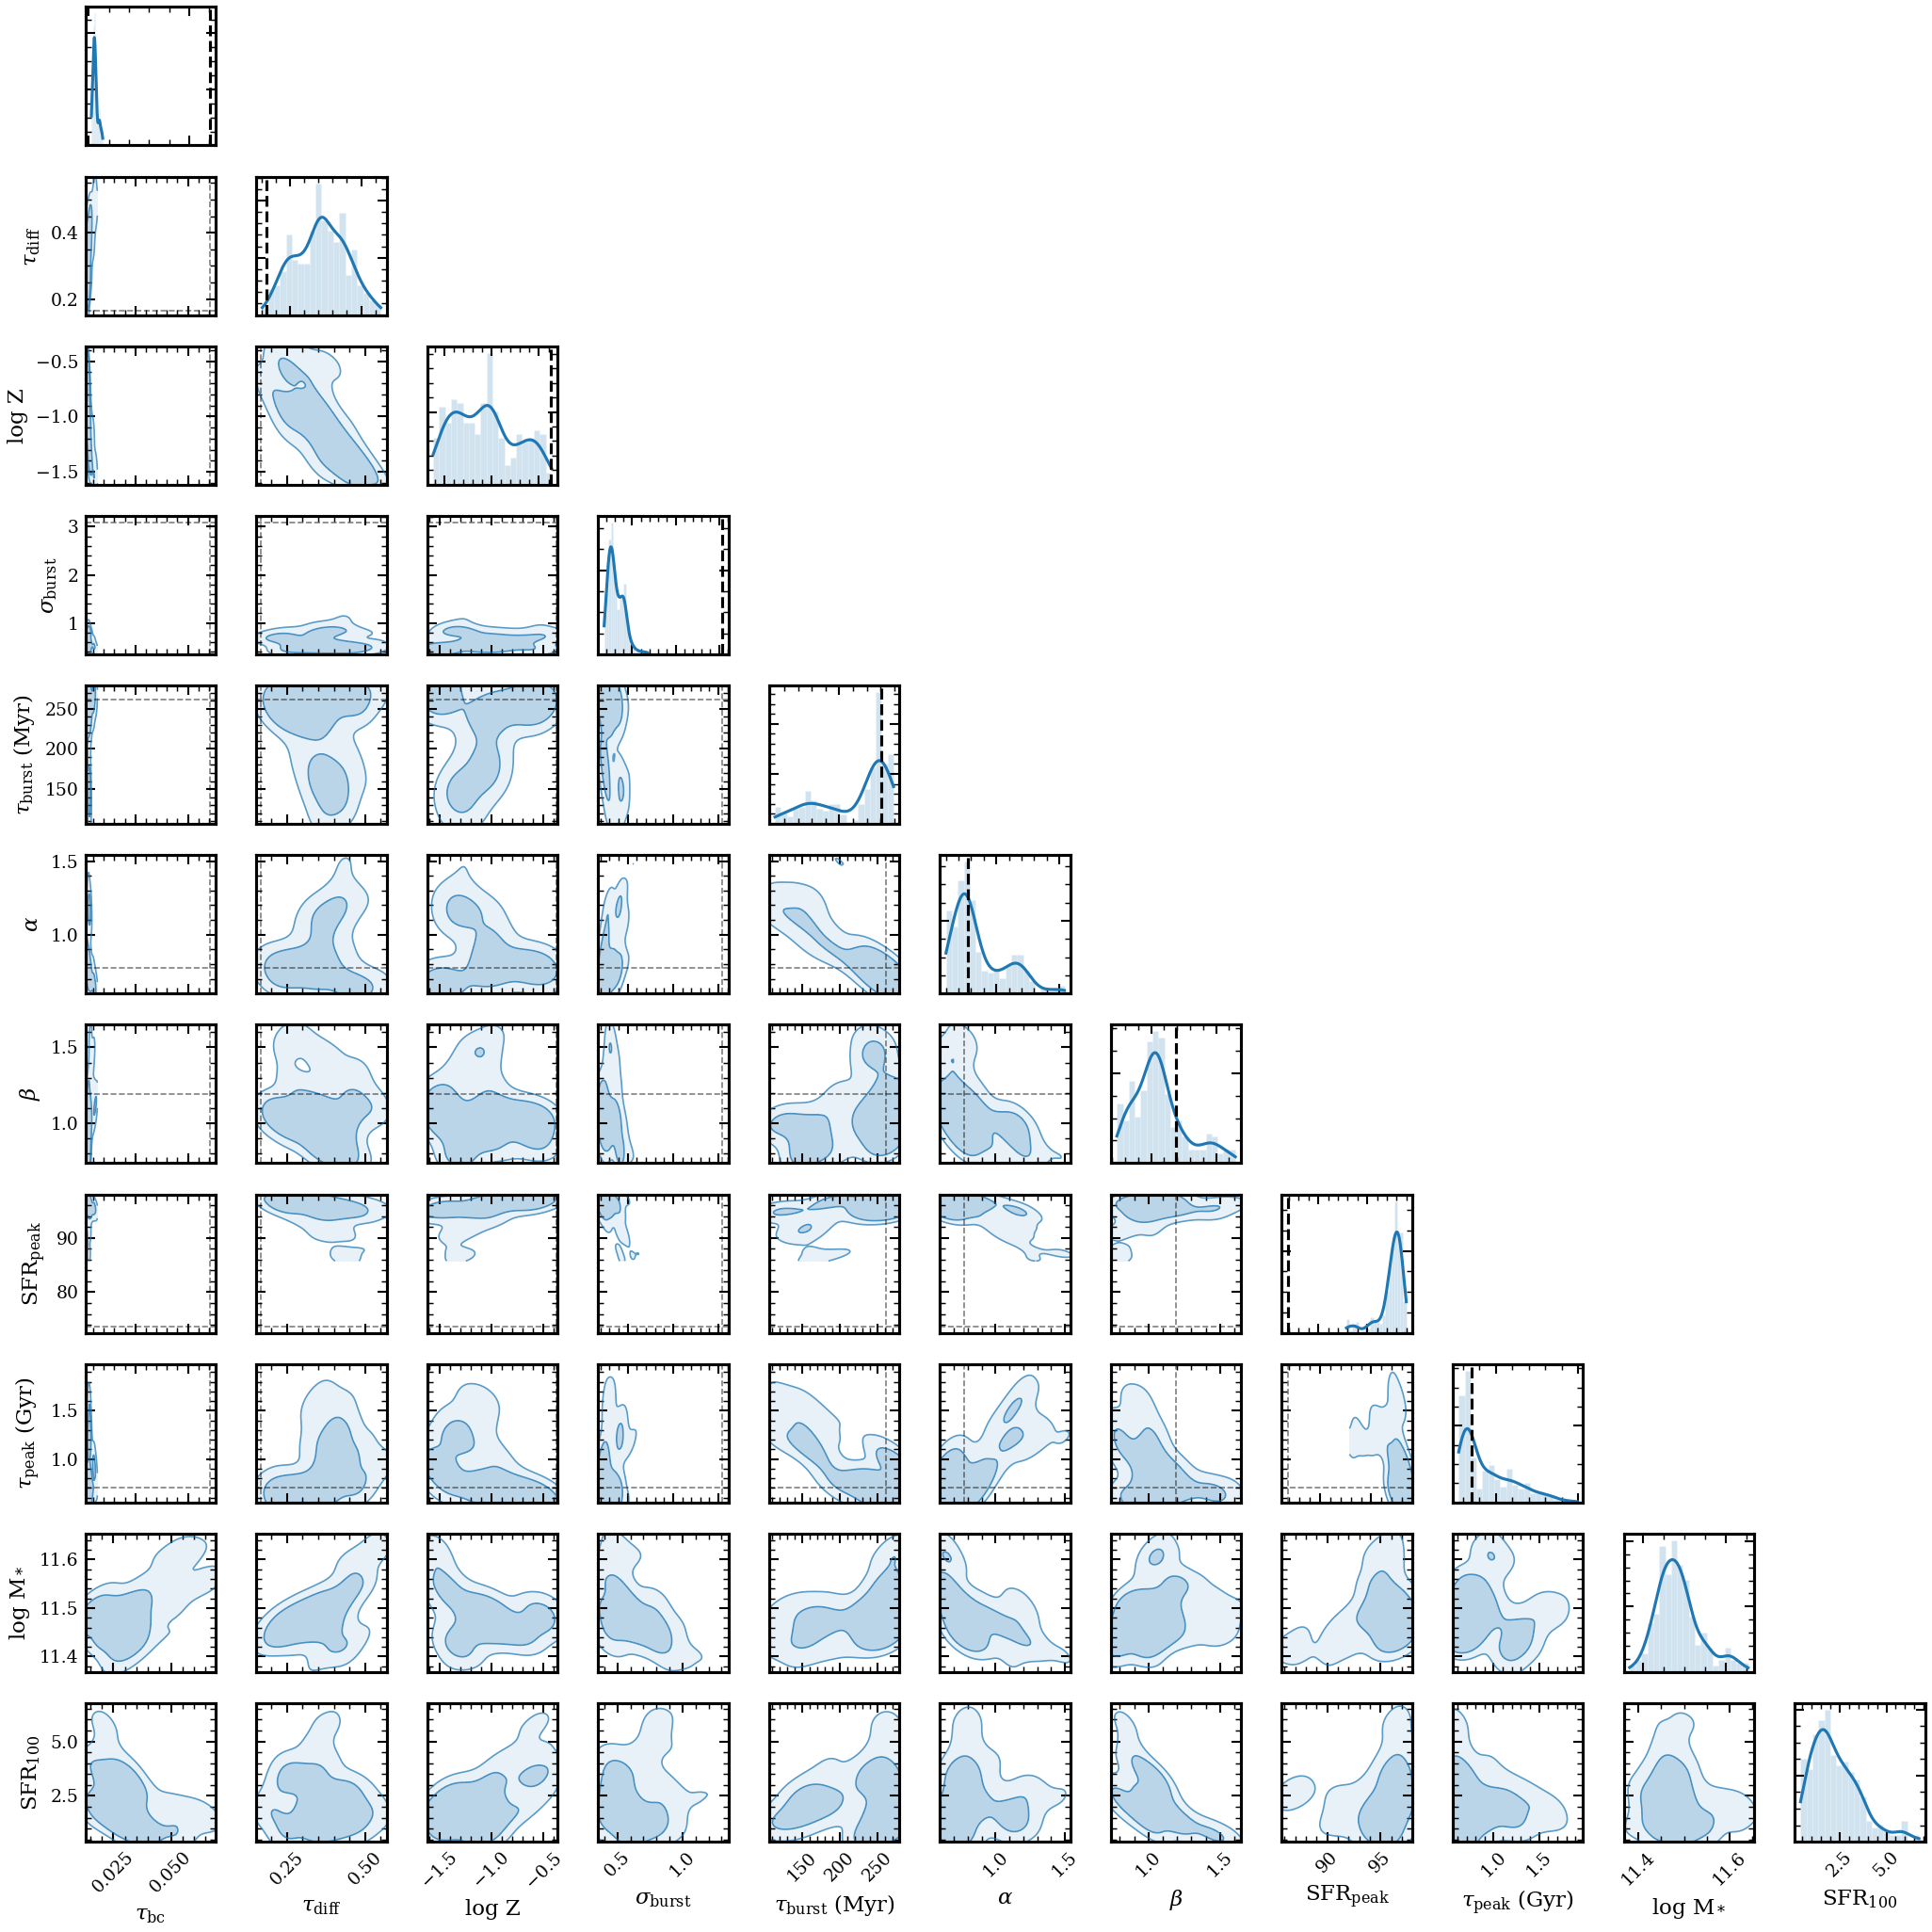

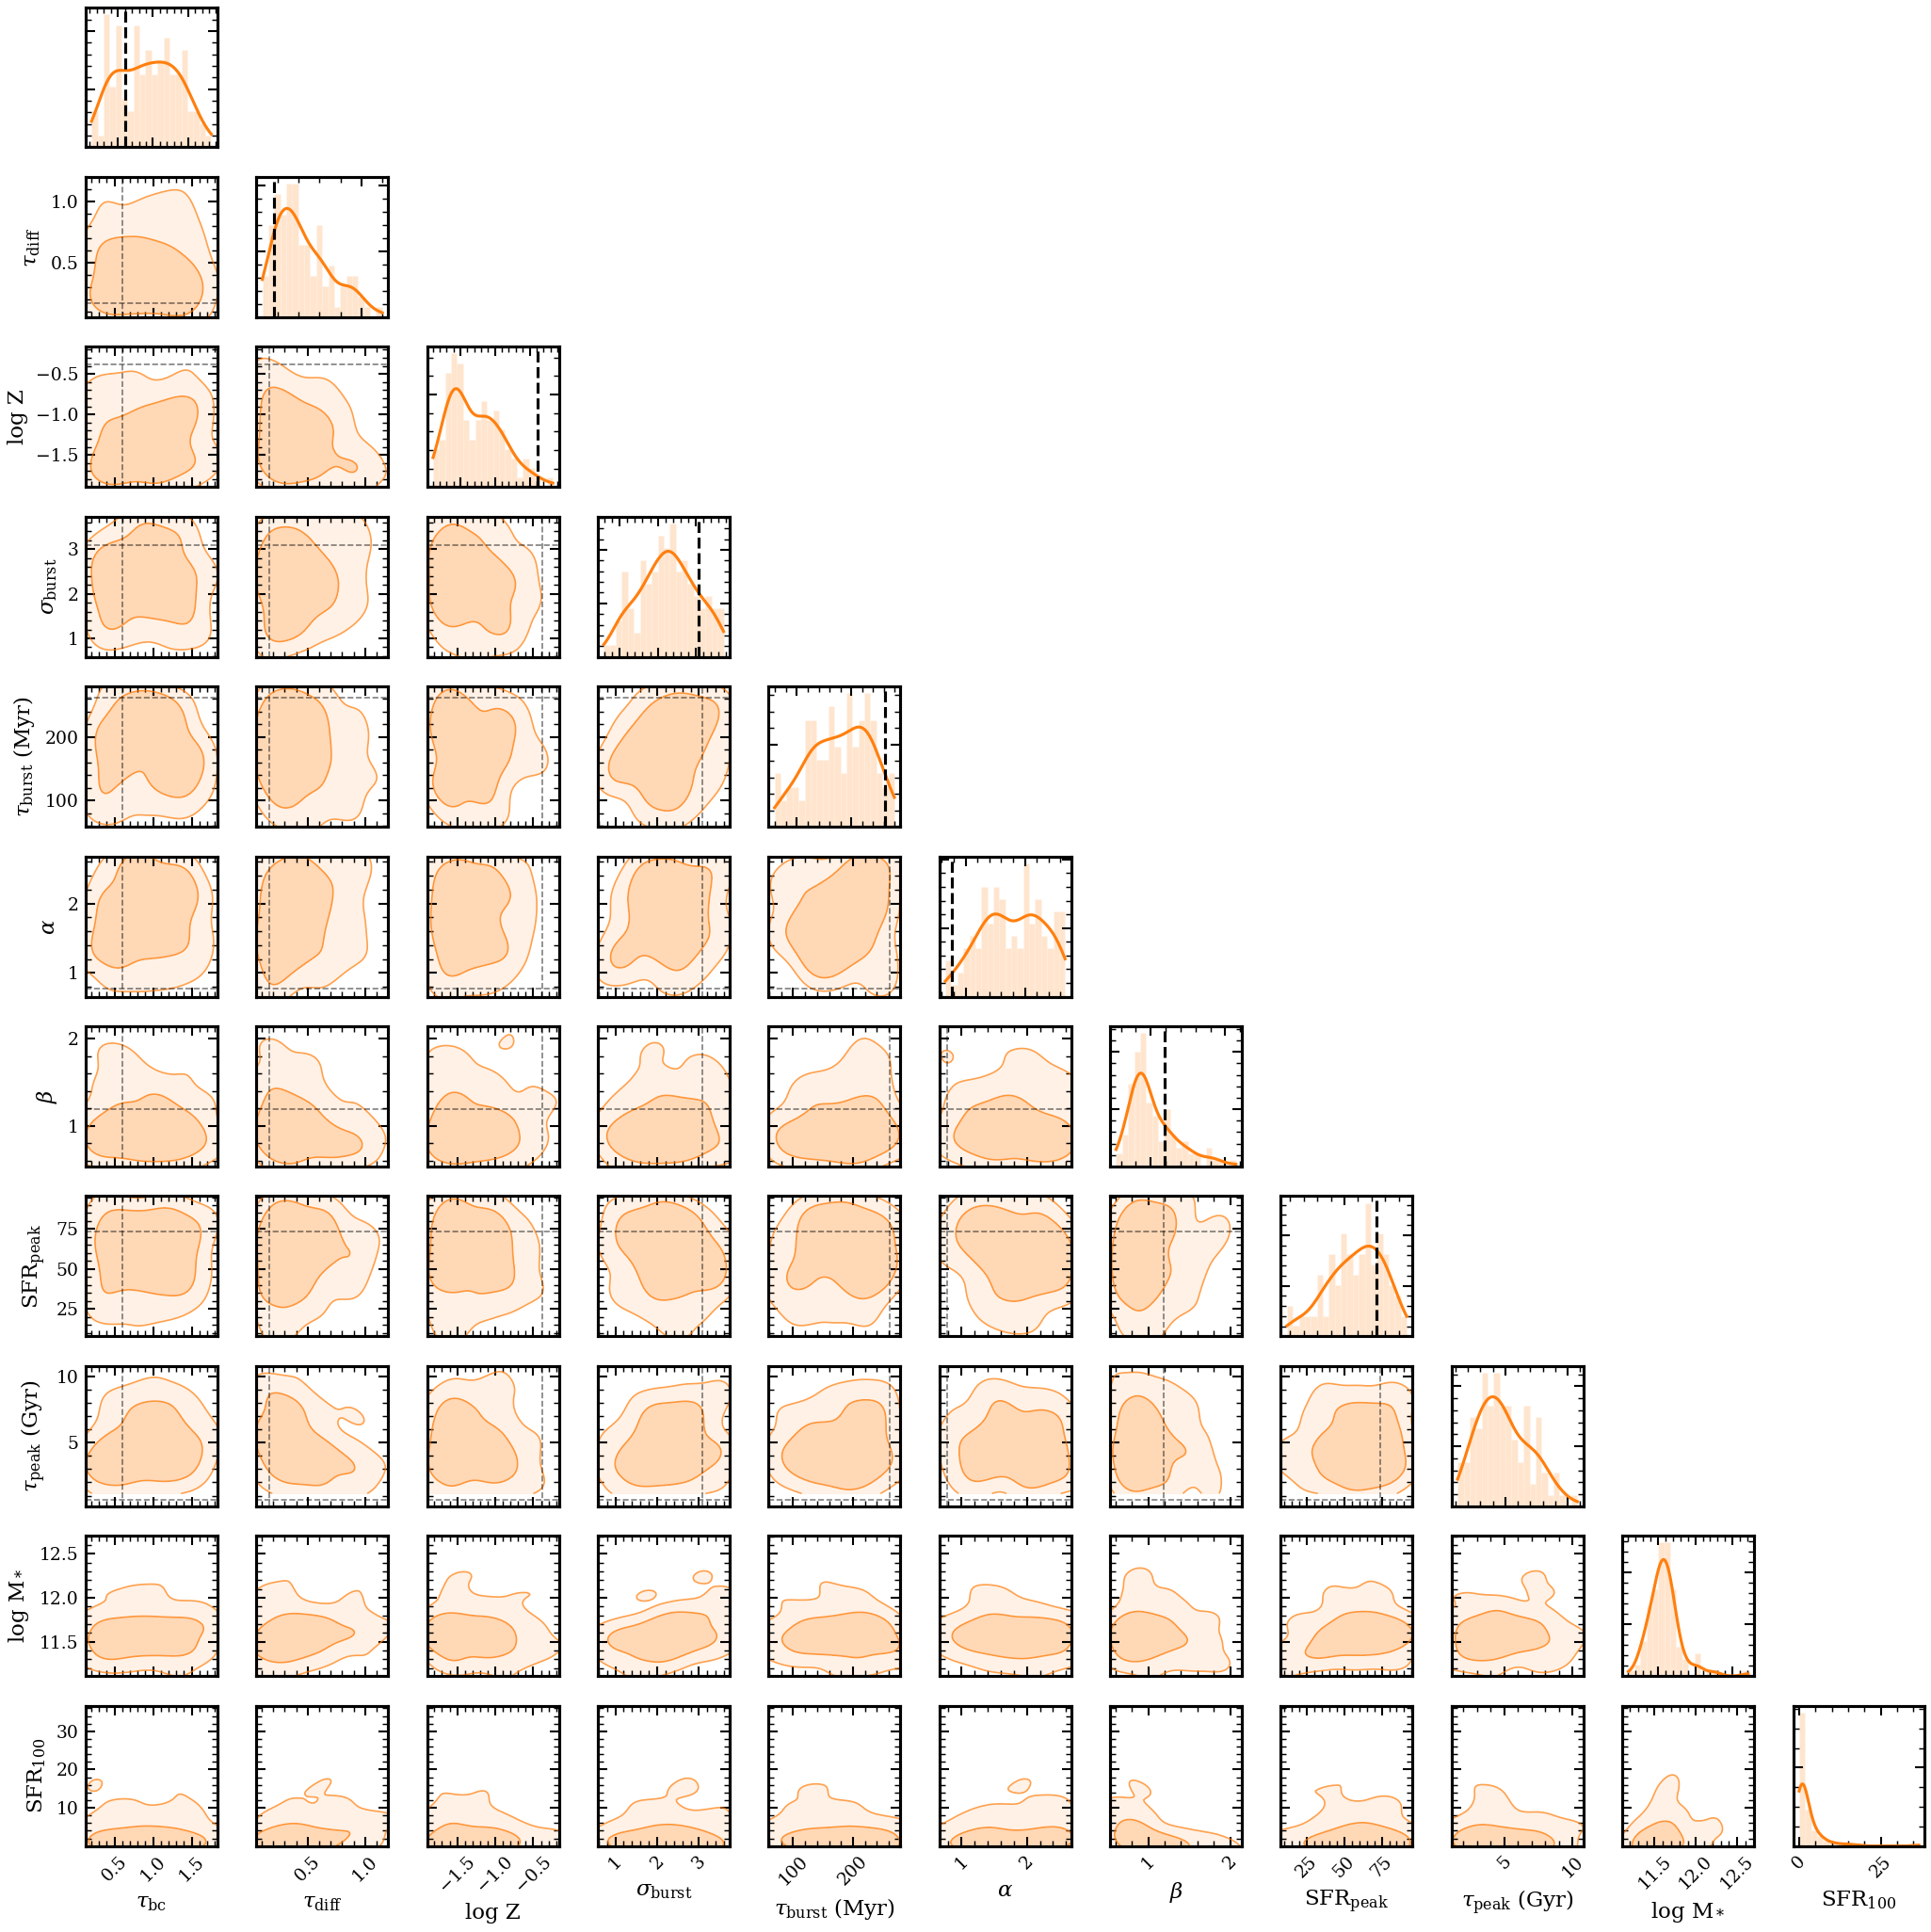

In [11]:
from _plot_style import plot_corner_comparison
plot_corner_comparison(
    [result_rt, result_geovi],
    ["Ray Tracing", "geoVI"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_params_stoch,
)
plt.show()

### Why not NUTS for the stochastic model?

NUTS relies on Hamiltonian dynamics that assume a smooth, deterministic
gradient of the log-posterior.  In the 137-D stochastic model the
likelihood gradient has intrinsic Monte Carlo noise, causing NUTS to
accumulate trajectory errors and diverge.  For $D \gtrsim 15$ with
stochastic gradients, **Ray Tracing** and **geoVI** are the recommended
inference methods.  NUTS remains the gold standard for low-dimensional
parametric models (Part A).

## What's Next?

- **[NB01 — The IFT Model](01_the_model.ipynb)**: PSD, GP theory,
  mean SFH, and the burstiness plane
- **[NB02 — Forward Model](02_forward_model.ipynb)**: SPS pipeline from
  SFH to photometry/spectroscopy
- **[NB03 — Inference Methods](03_inference_methods.ipynb)**: physics of
  RT, geoVI, NUTS — when to use which sampler
- **[NB04 — Recovery Tests](04_recovery_tests.ipynb)**: mock validation
  across regimes and data types
- **[NB05 — Hierarchical](05_hierarchical.ipynb)**: population-level PSD
  recovery — the Paper I key result
- **[NB06 — Data Information](06_data_information.ipynb)**: progressive
  reveal of how data constrains the model
- **[NB07 — Spectroscopy](07_spectroscopic_fitting.ipynb)**: fitting
  galaxy spectra and resolving degeneracies
- **[NB08 — PSD Physics](08_psd_physics.ipynb)**: connecting PSD
  parameters to astrophysical mechanisms
- **[NB09 — Custom Models](09_custom_models.ipynb)**: extending diffsed
  with new priors, PSD models, and dust laws